# 06 · Singularities and Manipulability

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/boelnasr/ManipulaPy/blob/notebooks/tutorials/notebooks/06_singularities.ipynb)

> **ManipulaPy teaching course — notebook 6 of 11.** Running robot: Franka Panda.

The Jacobian (notebook 03) maps joint rates to end-effector twists. At most configurations it has full rank and the arm can move its end-effector in every direction. At a **singularity** it loses rank: some direction of end-effector motion becomes instantaneously impossible, no matter how the joints move. Singularities are where resolved-rate control (notebook 03) and inverse kinematics (notebook 04) get into trouble — joint speeds blow up and the damping we added earns its keep. This notebook measures how close a configuration is to a singularity, and shows what is lost when it reaches one, using `ManipulaPy.singularity.Singularity`.

### Running on Colab or another cloud platform?

The next cell bootstraps the environment on Google Colab. It is a **no-op when you run locally** from a clone of the repo.

In [1]:
# Cloud bootstrap (no-op when running locally from the repo).
import sys
if "google.colab" in sys.modules:
    !git clone -q https://github.com/boelnasr/ManipulaPy.git
    %cd ManipulaPy/notebooks
    !pip install -q -e ..
    print("Colab setup complete.")

In [2]:
import os, sys
sys.path.insert(0, os.path.join(os.getcwd(), "_shared"))
from tikz import setup_pgf, embed_pgf_fig
import numpy as np
from helpers import load_panda, HOME, N_JOINTS
from ManipulaPy.singularity import Singularity
np.set_printoptions(precision=4, suppress=True)

sm, dyn = load_panda()
sing = Singularity(sm)
print("Panda loaded | singularity tools ready")

🤖 ManipulaPy v1.3.2.post1 loaded (lazy imports enabled)
   💡 Use ManipulaPy.check_dependencies() to see available features


pybullet build time: Jan 29 2025 23:16:28


Panda loaded | singularity tools ready


## 1. The Jacobian's singular values

Everything about singularities lives in the **singular value decomposition** of the Jacobian, $J=U\Sigma V^{\top}$. The singular values $\sigma_1\ge\dots\ge\sigma_6$ are the lengths of the manipulability ellipsoid's axes (notebook 03): the largest is the easiest direction of end-effector motion, the **smallest** $\sigma_6$ is the hardest. A singularity is exactly $\sigma_6=0$ — one axis of the ellipsoid has collapsed to a line, and that direction of motion is lost.

Three scalar summaries follow from the spectrum:

- **manipulability** $w=\sqrt{\det(JJ^{\top})}=\sigma_1\sigma_2\cdots\sigma_6$ — the ellipsoid's volume; $0$ at a singularity;
- the **smallest singular value** $\sigma_6$ — distance to rank loss in the worst direction;
- the **condition number** $\kappa=\sigma_1/\sigma_6$ — how lopsided the ellipsoid is; $\infty$ at a singularity.

In [3]:
J = sm.jacobian(HOME, frame='space')
sigmas = np.linalg.svd(J, compute_uv=False)
w = np.sqrt(np.linalg.det(J @ J.T))
print("singular values at HOME:", np.round(sigmas, 4))
print("manipulability  w = %.4f" % w)
print("smallest sigma_6 = %.4f" % sigmas[-1])
print("condition number = %.1f" % (sigmas[0] / sigmas[-1]))
assert np.isclose(w, np.prod(sigmas))      # w is the product of the singular values

singular values at HOME: [2.0035 1.8122 1.1663 0.3475 0.342  0.187 ]
manipulability  w = 0.0942
smallest sigma_6 = 0.1870
condition number = 10.7


Put `HOME` next to a **near-singular** configuration — most of the way from `HOME` toward the Panda's all-zero pose, which (we will see) is singular. The spectrum tells the story at a glance: the large singular values barely move, while $\sigma_6$ collapses toward zero. That single shrinking bar *is* the approach to rank loss.

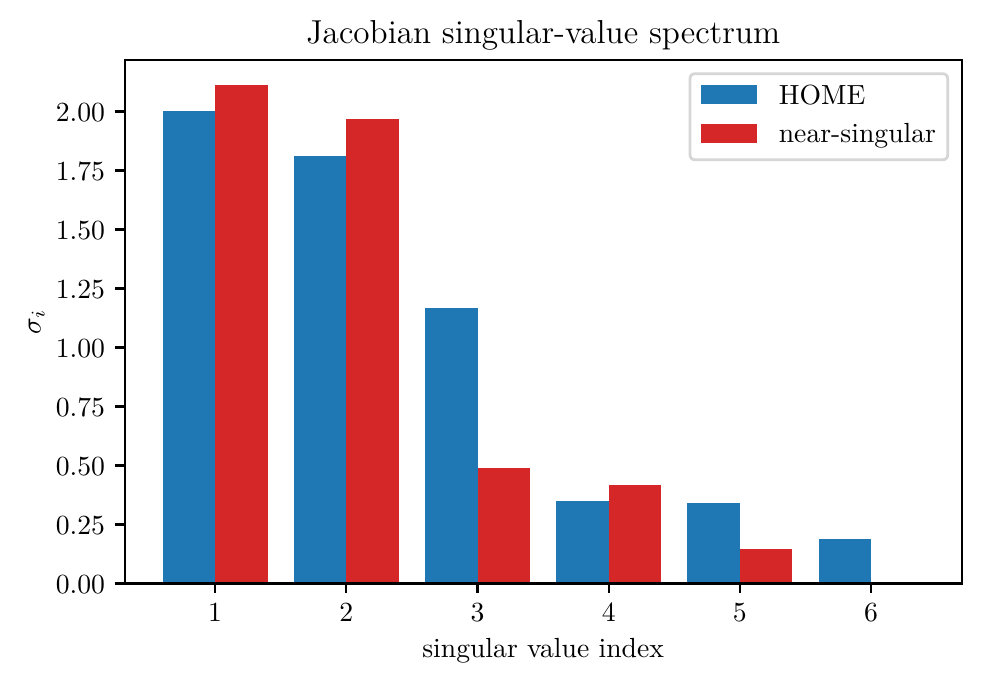

In [4]:
q_near = 0.235 * HOME             # the deepest near-singular point on the HOME->zero path
sig_home = np.linalg.svd(sm.jacobian(HOME, frame='space'), compute_uv=False)
sig_near = np.linalg.svd(sm.jacobian(q_near, frame='space'), compute_uv=False)

plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.4, 3.4))
x = np.arange(1, 7)
ax.bar(x - 0.2, sig_home, 0.4, label='HOME', color='tab:blue')
ax.bar(x + 0.2, sig_near, 0.4, label='near-singular', color='tab:red')
ax.set_xlabel('singular value index'); ax.set_ylabel('$\\sigma_i$')
ax.set_xticks(x); ax.set_title('Jacobian singular-value spectrum')
ax.legend()
embed_pgf_fig(fig, name="singular_value_spectrum")

### The manipulability ellipsoid in 3-D

Geometry makes "losing a direction" concrete. The end-effector linear velocities reachable with **unit-norm joint speed** form an ellipsoid whose semi-axes are the *linear* singular values. At `HOME` it is a healthy, rounded ellipsoid — the hand moves comfortably in every direction. At the near-singular pose it flattens into a **pancake**: its shortest axis ($\sigma\approx0.04$) is the direction the end-effector can barely move at all.

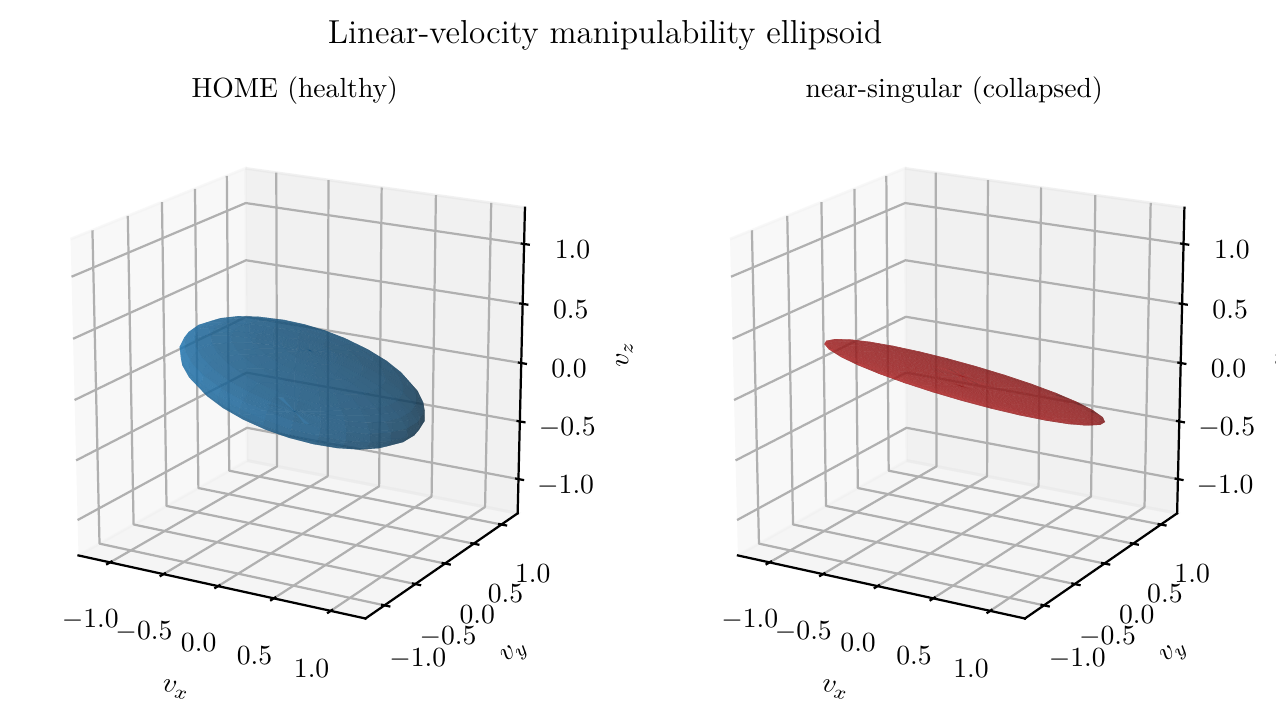

In [5]:
def linear_ellipsoid(q):
    Jv = sm.jacobian(q, frame='space')[3:6]          # linear-velocity rows
    U, S, _ = np.linalg.svd(Jv)
    u, v = np.mgrid[0:2 * np.pi:30j, 0:np.pi:15j]
    sphere = np.array([np.cos(u) * np.sin(v), np.sin(u) * np.sin(v), np.cos(v)])
    pts = U @ np.diag(S) @ sphere.reshape(3, -1)      # image of the unit sphere
    return [pts[k].reshape(u.shape) for k in range(3)]

plt = setup_pgf()
fig = plt.figure(figsize=(7.8, 3.8))
for k, (q, title, color) in enumerate(
        [(HOME, 'HOME (healthy)', 'tab:blue'),
         (q_near, 'near-singular (collapsed)', 'tab:red')], 1):
    ax = fig.add_subplot(1, 2, k, projection='3d')
    X, Y, Z = linear_ellipsoid(q)
    ax.plot_surface(X, Y, Z, color=color, alpha=0.6, linewidth=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('$v_x$'); ax.set_ylabel('$v_y$'); ax.set_zlabel('$v_z$')
    lim = 1.3
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
    ax.set_box_aspect((1, 1, 1)); ax.view_init(elev=18, azim=-60)
fig.suptitle('Linear-velocity manipulability ellipsoid')
embed_pgf_fig(fig, name="manipulability_ellipsoid_3d")

## 2. Approaching a singularity

Walk the arm continuously from `HOME` toward the all-zero pose and track all three measures. As the configuration approaches the singularity the manipulability $w$ and smallest singular value $\sigma_6$ plunge toward zero while the condition number $\kappa$ blows up — three views of the same collapse.

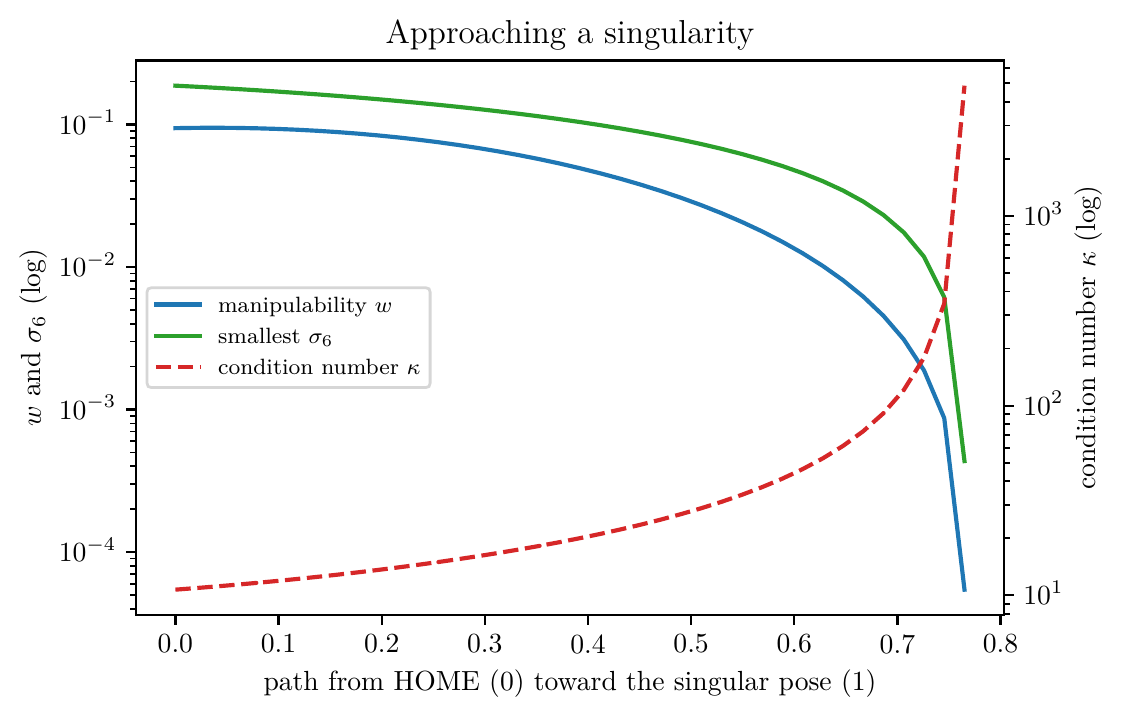

In [6]:
ts = np.linspace(0.0, 0.765, 40)     # 0 = HOME, 1 = all-zero (singular) pose
W, Smin, Cond = [], [], []
for t in ts:
    q = (1 - t) * HOME
    s = np.linalg.svd(sm.jacobian(q, frame='space'), compute_uv=False)
    W.append(np.prod(s)); Smin.append(s[-1]); Cond.append(s[0] / s[-1])

plt = setup_pgf()
fig, axL = plt.subplots(figsize=(5.6, 3.6))
axL.semilogy(ts, W, color='tab:blue', label='manipulability $w$')
axL.semilogy(ts, Smin, color='tab:green', label='smallest $\\sigma_6$')
axL.set_xlabel('path from HOME (0) toward the singular pose (1)')
axL.set_ylabel('$w$ and $\\sigma_6$ (log)')
axR = axL.twinx()
axR.semilogy(ts, Cond, color='tab:red', ls='--', label='condition number $\\kappa$')
axR.set_ylabel('condition number $\\kappa$ (log)')
lines = axL.get_lines() + axR.get_lines()
axL.legend(lines, [l.get_label() for l in lines], loc='center left', fontsize=8)
axL.set_title('Approaching a singularity')
embed_pgf_fig(fig, name="singularity_approach")

### The singularity landscape

That sweep followed one path; sweeping **two** joints maps manipulability over a whole slice of configuration space. Bright regions are dexterous, the dark trenches are where $w$ collapses toward a singularity. The structure is not a single point — singularities form **surfaces** the arm must steer around, which is exactly what makes them a planning concern (notebook 07).

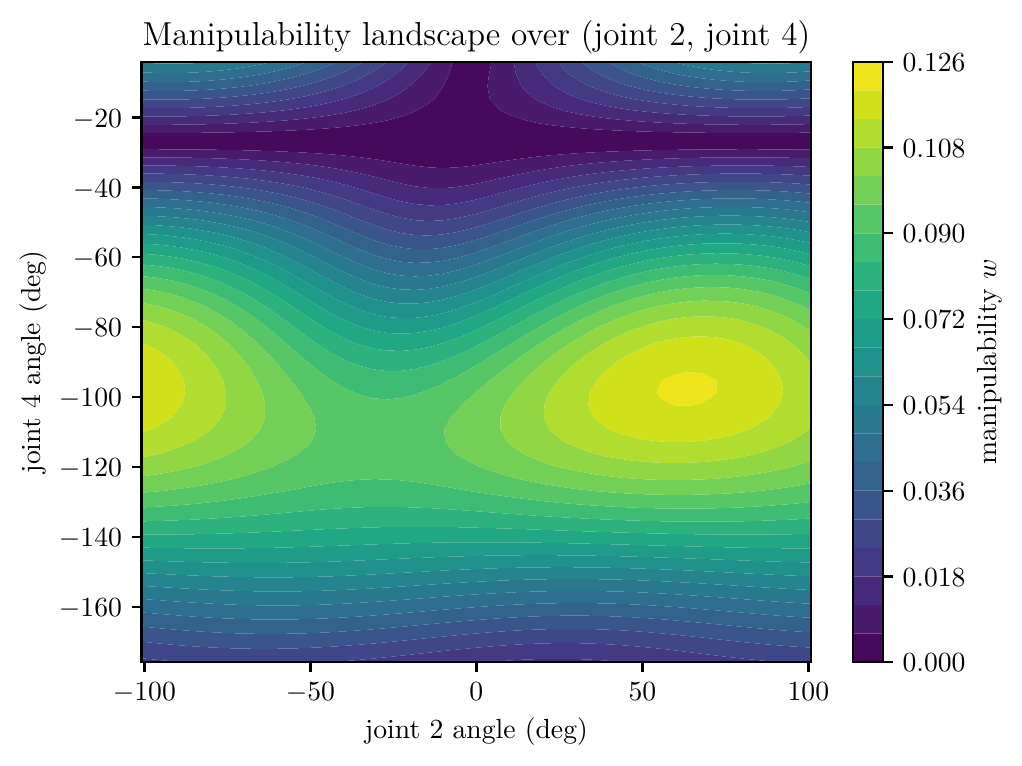

In [7]:
q2s = np.linspace(-1.76, 1.76, 50)
q4s = np.linspace(-3.07, -0.07, 50)
Wmap = np.zeros((len(q4s), len(q2s)))
for i, a in enumerate(q2s):
    for j, b in enumerate(q4s):
        q = HOME.copy(); q[1] = a; q[3] = b
        J = sm.jacobian(q, frame='space')
        Wmap[j, i] = np.sqrt(max(np.linalg.det(J @ J.T), 0))

plt = setup_pgf()
fig, ax = plt.subplots(figsize=(5.4, 3.9))
im = ax.contourf(np.degrees(q2s), np.degrees(q4s), Wmap, levels=20, cmap='viridis')
fig.colorbar(im, ax=ax, label='manipulability $w$')
ax.set_xlabel('joint 2 angle (deg)'); ax.set_ylabel('joint 4 angle (deg)')
ax.set_title('Manipulability landscape over (joint 2, joint 4)')
embed_pgf_fig(fig, name="manipulability_landscape")

## 3. Detecting a singularity

`singularity_analysis` returns a boolean — it flags a configuration as singular when the smallest singular value drops below $10^{-4}$. The Panda's **all-zero pose** is a genuine singularity (its Jacobian is exactly rank-deficient), so the detector fires there and not at `HOME`. `condition_number` gives the underlying $\kappa$ as a number.

In [8]:
q_singular = np.zeros(N_JOINTS)         # the Panda's all-zero pose
print("HOME       : singular? %-5s  condition number %.1f"
      % (sing.singularity_analysis(HOME), sing.condition_number(HOME)))
print("all-zero   : singular? %-5s  condition number %.1e"
      % (sing.singularity_analysis(q_singular), sing.condition_number(q_singular)))
assert not sing.singularity_analysis(HOME)
assert sing.singularity_analysis(q_singular)

# near_singularity_detection wraps the condition number against a cutoff you choose
# (kappa >= 1 always, so pick a value like 50-100 for 'near singular', not the
# permissive default).
print("near-singular by kappa>50?  HOME:", sing.near_singularity_detection(HOME, threshold=50),
      " near pose:", sing.near_singularity_detection(q_near, threshold=50))

HOME       : singular? False  condition number 10.7
all-zero   : singular? True   condition number inf
near-singular by kappa>50?  HOME: False  near pose: True


## 4. What is lost, and why it matters

At a singularity the lost direction is the column of $U$ paired with $\sigma_6$: the end-effector simply cannot be moved that way by any joint motion. Just *near* a singularity the direction is still available, but only at a steep price — producing one unit of end-effector velocity along it needs joint speeds of order $1/\sigma_6$. As $\sigma_6\to0$ that cost explodes, which is exactly why the resolved-rate pseudoinverse (notebook 03) and the inverse kinematics step (notebook 04) blow up near singularities — and why the **damped** least-squares solver, which caps that $1/\sigma_6$ factor, is the standard fix.

In [9]:
for label, q in [('HOME', HOME), ('near-singular', q_near)]:
    s6 = np.linalg.svd(sm.jacobian(q, frame='space'), compute_uv=False)[-1]
    print('%-13s sigma_6 = %.4f  ->  worst-direction joint-speed cost ~ 1/sigma_6 = %5.1f'
          % (label, s6, 1.0 / s6))

# Moving the end-effector in its hardest direction costs far more joint speed
# near the singularity than at HOME.
s6_home = np.linalg.svd(sm.jacobian(HOME, frame='space'), compute_uv=False)[-1]
s6_near = np.linalg.svd(sm.jacobian(q_near, frame='space'), compute_uv=False)[-1]
assert (1 / s6_near) > 3 * (1 / s6_home)

HOME          sigma_6 = 0.1870  ->  worst-direction joint-speed cost ~ 1/sigma_6 =   5.3
near-singular sigma_6 = 0.0004  ->  worst-direction joint-speed cost ~ 1/sigma_6 = 2298.9


## Smoke test

Asserts the key invariants of this notebook in one cell.

In [10]:
sm2, _ = load_panda()
sg2 = Singularity(sm2)
J = sm2.jacobian(HOME, frame='space')
s = np.linalg.svd(J, compute_uv=False)
# Manipulability is the product of the singular values, positive away from singularities.
assert np.isclose(np.sqrt(np.linalg.det(J @ J.T)), np.prod(s))
assert s[-1] > 1e-4
# HOME is well-conditioned; the all-zero pose is singular.
assert not sg2.singularity_analysis(HOME)
assert sg2.singularity_analysis(np.zeros(N_JOINTS))
# Condition number grows toward the singular pose.
assert sg2.condition_number(0.235 * HOME) > sg2.condition_number(HOME)
print("nb06 singularities: smoke OK")

nb06 singularities: smoke OK


## Try it

1. Find the column of $U$ (from `np.linalg.svd(J, full_matrices=True)`) paired with $\sigma_6$ at the near-singular pose — that twist is the direction the end-effector struggles to move. Confirm `joint_velocity` for that twist returns very large joint rates.
2. Re-solve that same twist with the damped pseudoinverse $J^{\top}(JJ^{\top}+\lambda^2 I)^{-1}$ for a few $\lambda$ and watch the joint rates stay bounded — the notebook 04 fix, seen from the singularity side.
3. Sweep a different joint (e.g. joint 6) and see whether you can drive $w$ to a local minimum — not every joint reaches a singularity within its limits.

*Next up — notebook 07: **control** — turning the dynamics of notebook 05 into torques that track a desired motion.*

## References

1. K. M. Lynch and F. C. Park, *Modern Robotics: Mechanics, Planning, and Control*, Cambridge University Press, 2017. — Chapter 5, *Velocity Kinematics and Statics* (singularities, manipulability ellipsoid).
2. T. Yoshikawa, *Manipulability of Robotic Mechanisms*, Int. J. Robotics Research, 1985. — Origin of the manipulability measure $w=\sqrt{\det(JJ^{\top})}$.
3. B. Siciliano, L. Sciavicco, L. Villani, and G. Oriolo, *Robotics: Modelling, Planning and Control*, Springer, 2009. — Singularities and damped least squares.
4. ManipulaPy documentation — https://manipulapy.readthedocs.io/ · source — https://github.com/boelnasr/ManipulaPy
